**SAPIANS** · SCC5819 · MÓDULO 05 — SHAP · MOLNAR, CAPS. 17–18

# SHAP — um passo a passo no modelo COVID

O módulo 04 perguntou o que *mudaria* a decisão; ficou de fora quanto cada
campo já contribuiu para a decisão que está posta — e é essa repartição,
a única do curso com garantia de **soma**, que fecha o arco dos cinco
métodos.

[README do módulo](../README.md) · [companheiro técnico](shap_internals.ipynb) · [modelo do curso](../../00-dataset/MODEL.md) · [outline da aula](../lecture/outline.md)

---

240 mil internações reais por SRAG-COVID (a amostra do módulo 00:
validação e teste inteiros), o XGBoost do curso, e a atribuição exata que
já mora dentro dele. Construímos os cinco gráficos clássicos do cap. 18
do Molnar — waterfall, force, beeswarm, importância global, dependence —
em matplotlib puro sobre `pred_contribs`, e medimos o que cada um pode e
não pode dizer.

**Objetivos.**

1. Enunciar o que um valor de Shapley é (o jogo, o ganho, a coalizão) e
   citar os quatro axiomas — com a eficiência **verificada em ponto
   flutuante** neste modelo, não assumida.
2. Ler os cinco gráficos clássicos do SHAP e apontar, em cada um, o que
   é axioma e o que é estimativa.
3. Dar a interpretação correta de um φ ("contribuiu φ em relação à
   predição média") e desarmar as três leituras erradas mais comuns —
   contrafactual, causal, e "φ>0 ⇒ aumentar a feature aumenta p".
4. Distinguir os condicionamentos *path-dependent* e *interventional*, e
   medir o custo escondido do segundo: coalizões que são pacientes
   impossíveis.

Tudo que este notebook afirma é impresso por uma célula dele ou do
companheiro `shap_internals.ipynb`; a comparação com o LIME usa o mesmo
paciente e a mesma lib pinada do módulo 03.

In [1]:
%pip install -q lime xgboost scikit-learn scipy matplotlib numpy pandas pyarrow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pathlib
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgblib
from matplotlib.colors import LinearSegmentedColormap
from scipy.special import expit

pd.set_option("display.width", 120)
RANDOM_STATE = 42

REPO = pathlib.Path.cwd()
while REPO != REPO.parent and not (REPO / "tools" / "README.md").exists():
    REPO = REPO.parent
if not (REPO / "tools" / "README.md").exists():
    import tempfile
    REPO = pathlib.Path(tempfile.gettempdir()) / "interpretable-ml-lectures"
    if not REPO.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/wbendinelli/interpretable-ml-lectures.git",
                        str(REPO)], check=True)
sys.path.insert(0, str(REPO / "tools"))
import sapians as SP
import srag_60_model as M

SP.aplicar()

# a rampa de intensidade cortada na ponta clara: abaixo de ~0,3 ela some no
# papel branco (o mesmo corte que SP.rampa faz na lista discreta). Usada nos
# gráficos em que a cor codifica o VALOR de uma feature, não o sinal de phi.
RAMPA = LinearSegmentedColormap.from_list(
    "intensidade_visivel", SP.CMAP_INTENSIDADE(np.linspace(0.30, 1.0, 256)))

g = M.load_gold(REPO / "modules/00-dataset/gold/gold_covid_obito_sample.parquet")
xgb, _logit = M.fit_models(g)
paciente = M.pick_exemplar(xgb, g)
booster = xgb.get_booster()


def dmatrix(frame):
    x, _, _ = M.design_matrix(frame)
    return xgblib.DMatrix(x, enable_categorical=True)


teste = g[g["split"] == "test"].reset_index(drop=True)
dm_teste = dmatrix(teste)
contrib = booster.predict(dm_teste, pred_contribs=True)
margem = booster.predict(dm_teste, output_margin=True)
NOMES = list(M.FEATURES) + ["base"]

desvio = float(np.abs(contrib.sum(axis=1) - margem).max())
print(f"contribuições no teste: {contrib.shape[0]:,} × {contrib.shape[1]} "
      f"(40 features + base)".replace(",", "."))
print(f"eficiência, verificada: |soma das contribuições − margem| máximo = {desvio:.2e}")
print(f"base value (margem): {contrib[0, -1]:.4f} — sigmoide {expit(contrib[0, -1]):.4f} "
      f"(a taxa de óbito do treino é 0,3136 — internals §2)")

ix = teste.index[teste["gold_id"] == int(paciente["gold_id"])][0]
c_pac = contrib[ix]
print(f"paciente-regra gold_id {int(paciente['gold_id'])}: soma + base = "
      f"{float(c_pac.sum()):+.4f} (margem) -> sigmoide {expit(float(c_pac.sum())):.4f} "
      f"= p do modelo {paciente['p_obito']:.4f}")

contribuições no teste: 16.142 × 41 (40 features + base)
eficiência, verificada: |soma das contribuições − margem| máximo = 1.05e-05
base value (margem): -0.7881 — sigmoide 0.3126 (a taxa de óbito do treino é 0,3136 — internals §2)
paciente-regra gold_id 1276776: soma + base = +0.0000 (margem) -> sigmoide 0.5000 = p do modelo 0.5000


## O que o SHAP é

Um valor de Shapley (1953) responde a uma pergunta de teoria dos jogos:
como repartir com justiça o ganho de uma coalizão entre os jogadores?
Lundberg & Lee (2017) fizeram da predição um jogo — e o Molnar (cap. 17)
o define em uma frase: o **jogo** é a tarefa de predição para uma
instância; o **ganho** é a predição dela menos a predição média; os
**jogadores** são os valores das features, que cooperam para produzir o
ganho.

$$\phi_j = \sum_{S \subseteq F \setminus \{j\}} \frac{|S|!\,(|F|-|S|-1)!}{|F|!}\,\big[f(S \cup \{j\}) - f(S)\big]$$

| símbolo | o que é | aqui |
|---|---|---|
| $F$ | os jogadores | as 40 features do modelo do curso |
| $S$ | uma coalizão | um subconjunto de features "presentes" |
| $f(S)$ | o valor da coalizão | a predição com as ausentes marginalizadas |
| $\phi_j$ | a parte justa do jogador $j$ | a contribuição da feature, em **margem** (log-odds) |
| ganho | $f(x) - \mathbb{E}[f]$ | margem do paciente − base value |

A soma exata tem $2^{40}$ coalizões — impraticável em geral. Este módulo
usa o **TreeSHAP** (Lundberg et al., 2020), que calcula o valor exato em
tempo polinomial explorando a estrutura das árvores, e que o XGBoost
expõe como `pred_contribs=True`. A biblioteca `shap` fica fora — no
stack pinado a resolução dela exige um numba/llvmlite que não constrói
aqui, e a decisão (com critério de falsificação) está no PR do pin. O
que se perde são os gráficos prontos; este notebook os refaz.

**Os quatro axiomas (cap. 17)** — Shapley é a única atribuição que
satisfaz os quatro:

- **Eficiência** — "the feature contributions must add up to the
  difference of prediction for x and the average". Verificada acima:
  desvio máximo 1,05×10⁻⁵ em 16.142 pacientes.
- **Simetria** — jogadores idênticos em toda coalizão recebem o mesmo φ.
- **Dummy** — "a feature that does not change the predicted value —
  regardless of which coalition — should have a Shapley value of 0"
  (internals §1 mede no nosso modelo).
- **Aditividade** — o φ de um ensemble é a soma dos φ das árvores — o
  motivo de o TreeSHAP existir.

As contribuições vivem na **margem**, não na probabilidade: é o espaço
em que somar 800 árvores faz sentido. As figuras anotam a sigmoide nos
pontos que importam.

## O paciente, e as ferramentas de desenho

O paciente-regra dos módulos 01–03: $|p-0{,}5|$ mínimo no teste, empate
por `gold_id` — o curso inteiro explica **o mesmo caso**, e a comparação
do §3 (SHAP × LIME) só é honesta por isso. A predição dele é 0,5000 — a
margem soma exatamente 0, e o waterfall vai mostrar o cabo de guerra que
produz esse empate.

Convenção de cores, a mesma dos módulos 01–04: **terracota** empurra a
predição para cima (óbito, φ > 0), **azul** segura para baixo (sobrevida,
φ < 0), **cinza-claro** é neutro/desconhecido. Nos gráficos globais a cor
troca de trabalho — deixa de marcar o sinal de φ e passa a codificar o
**valor** da feature, numa rampa ordinal de intensidade (claro = baixo →
escuro = alto). Onde a comparação não é sobre classe (SHAP × LIME no §3,
caminho × intervenção no §6), o segundo braço vai de **âmbar**, para que
o par azul/terracota continue querendo dizer só uma coisa.

## §1 — Waterfall: da média até este paciente

O gráfico-assinatura do SHAP: começa na predição de quem não sabe nada
(o base value, sigmoide 0,31 — a prevalência do treino, internals §2) e
soma uma contribuição por vez até chegar em $f(x)$.

as 9 maiores contribuições (margem), com o valor do paciente:
  idade_anos                 +0.9231   (valor: 89.7)
  vacina_covid_declarada     -0.3562   (valor: True)
  meses_desde_mar2020        -0.3235   (valor: 53.6)
  cs_zona                    +0.1558   (valor: desconhecido)
  desc_resp                  +0.1142   (valor: sim)
  saturacao                  +0.1085   (valor: sim)
  semana_epi                 -0.1029   (valor: 34)
  n_doses_antes_do_sintoma   +0.0987   (valor: 1)
  cs_sexo                    +0.0769   (valor: masculino)
  31 outras features         +0.0935
base -0.7881 (p 0.313)  ->  f(x) +0.0000 (p 0.500)


figura: figures_generated/shap_passo_1_waterfall.png


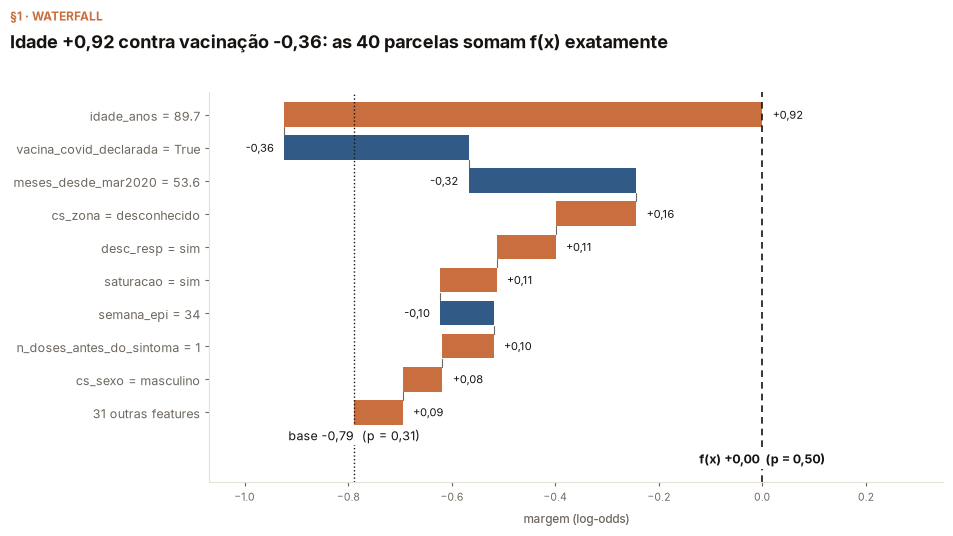

In [3]:
o = np.argsort(-np.abs(c_pac[:-1]))
topo = list(o[:9])
resto = list(o[9:])
phi_resto = float(c_pac[resto].sum())
base = float(c_pac[-1])
fx = float(c_pac.sum())


def fmt(v):
    return f"{float(v):.1f}" if isinstance(v, (int, float, np.floating)) else str(v)


print("as 9 maiores contribuições (margem), com o valor do paciente:")
for j in topo:
    print(f"  {NOMES[j]:26s} {c_pac[j]:+.4f}   (valor: {fmt(paciente[NOMES[j]])})")
print(f"  {'31 outras features':26s} {phi_resto:+.4f}")
print(f"base {base:+.4f} (p {expit(base):.3f})  ->  f(x) {fx:+.4f} (p {expit(fx):.3f})")

# cor = sinal de phi, o par de classe do curso: terracota empurra para óbito,
# azul segura para sobrevida. O fio entre as barras é construto nosso (cinza);
# base e f(x) são objeto do modelo (escuro), o f(x) no traço da fronteira.
linhas = [("31 outras features", phi_resto, "")] + [
    (NOMES[j], float(c_pac[j]), f" = {fmt(paciente[NOMES[j]])}") for j in reversed(topo)
]
fig, ax = plt.subplots(figsize=SP.SLOT)
acum = base
for k, (nome, phi, val) in enumerate(linhas):
    cor = SP.TERRACOTA if phi > 0 else SP.AZUL
    ax.barh(k, phi, left=acum, height=0.75, color=cor)
    ax.text(acum + phi + (0.02 if phi > 0 else -0.02), k, SP.pt(phi, 2, sinal=True),
            va="center", ha="left" if phi > 0 else "right", fontsize=8)
    acum += phi
    if k < len(linhas) - 1:
        ax.plot([acum, acum], [k + 0.38, k + 0.62], color=SP.CINZA, lw=0.8)
ax.set_yticks(range(len(linhas)),
              [f"{n}{v}" for n, _, v in linhas], fontsize=9)
ax.axvline(base, color=SP.ESCURO, lw=1, ls=":")
ax.axvline(fx, **SP.L_FRONTEIRA)
ax.text(base, -0.85, f"base {SP.pt(base, 2, sinal=True)}  (p = {SP.pt(expit(base), 2)})",
        ha="center", fontsize=9,
        bbox=dict(facecolor=SP.PAPEL, edgecolor="none", pad=1.5))
ax.text(fx, -1.55, f"f(x) {SP.pt(fx, 2, sinal=True)}  (p = {SP.pt(expit(fx), 2)})",
        ha="center", fontsize=9, fontweight="bold",
        bbox=dict(facecolor=SP.PAPEL, edgecolor="none", pad=1.5))
ax.set_ylim(-2.1, len(linhas) - 0.3)
ax.set_xlim(base - 0.28, 0.35)
ax.set_xlabel("margem (log-odds)")
SP.sem_grade(ax)
phi_idade = float(c_pac[NOMES.index("idade_anos")])
phi_vacina = float(c_pac[NOMES.index("vacina_covid_declarada")])
SP.titulo(fig,
          f"Idade {SP.pt(phi_idade, 2, sinal=True)} contra vacinação "
          f"{SP.pt(phi_vacina, 2, sinal=True)}: as 40 parcelas somam f(x) exatamente",
          "§1 · waterfall")
SP.salvar(fig, "shap_passo_1_waterfall")
plt.show()

**O que olhar**

- As barras *somam exatamente*: base -0,7881 mais as 40 contribuições dá
  f(x) +0,0000, sigmoide 0,500. É o axioma da eficiência (desvio máximo
  1,05×10⁻⁵ no teste inteiro, impresso no setup), não um ajuste de escala.
- O cabo de guerra do empate: idade 89,7 puxa +0,9231 para óbito, a
  vacinação declarada devolve -0,3562, o calendário -0,3235 e a zona
  desconhecida +0,1558.
- As "31 outras features" somam +0,0935 — φ pequeno não é φ zero, e o
  waterfall as agrega em vez de escondê-las (o dummy é testado no
  internals §1).
- Compare com o módulo 03: os pesos do LIME não deviam a soma a ninguém;
  aqui a soma **é** a predição.

## §2 — Force plot: as mesmas forças, numa linha

O force plot do livro é o waterfall deitado: as forças terracota empurram
a partir da base para a direita, as azuis seguram, e o ponto de
equilíbrio é $f(x)$. Molnar o lê como "features as forces" — cada valor
de feature é uma força que aumenta ou diminui a predição.

figura: figures_generated/shap_passo_2_force.png


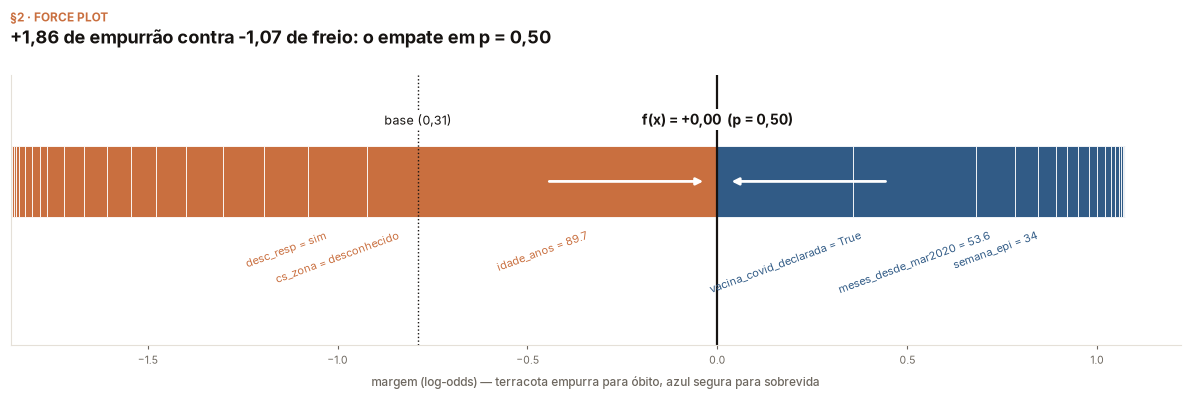

forças: +1.86 (terracota) contra −1.07 (azul); base -0.79 + 1.86 − 1.07 = f(x) +0.00 — a eficiência, visível


In [4]:
positivos = sorted([j for j in range(40) if c_pac[j] > 0], key=lambda j: c_pac[j])
negativos = sorted([j for j in range(40) if c_pac[j] <= 0], key=lambda j: c_pac[j])
soma_pos = float(c_pac[positivos].sum())
soma_neg = float(-c_pac[negativos].sum())

# mesmo par de classe do §1; o fio que separa as forças é o próprio papel, e as
# duas verticais (base e f(x)) são objeto do modelo, em escuro.
fig, ax = plt.subplots(figsize=SP.FAIXA)
# terracota: empurram para a direita e terminam em f(x); o maior encosta em f(x)
x = fx - soma_pos
rot_pos = positivos[-3:]
for j in positivos:
    phi = float(c_pac[j])
    ax.barh(0, phi, left=x, height=0.5, color=SP.TERRACOTA,
            edgecolor=SP.PAPEL, linewidth=0.6)
    if j in rot_pos and phi > 0.08:
        ax.annotate(f"{NOMES[j]} = {fmt(paciente[NOMES[j]])}",
                    xy=(x + phi / 2, -0.33), ha="center", va="top",
                    fontsize=8, rotation=20, color=SP.TERRACOTA)
    x += phi
# azuis: seguram a partir de f(x); o maior encosta em f(x)
x = fx
rot_neg = negativos[:3]
for j in negativos:
    phi = float(-c_pac[j])
    ax.barh(0, phi, left=x, height=0.5, color=SP.AZUL,
            edgecolor=SP.PAPEL, linewidth=0.6)
    if j in rot_neg and phi > 0.08:
        ax.annotate(f"{NOMES[j]} = {fmt(paciente[NOMES[j]])}",
                    xy=(x + phi / 2, -0.33), ha="center", va="top",
                    fontsize=8, rotation=20, color=SP.AZUL)
    x += phi
ax.axvline(fx, color=SP.ESCURO, lw=1.6)
ax.axvline(base, color=SP.ESCURO, lw=1, ls=":")
ax.text(fx, 0.40, f"f(x) = {SP.pt(fx, 2, sinal=True)}  (p = {SP.pt(expit(fx), 2)})",
        ha="center", fontsize=10, fontweight="bold",
        bbox=dict(facecolor=SP.PAPEL, edgecolor="none", pad=1.5))
ax.text(base, 0.40, f"base ({SP.pt(expit(base), 2)})", ha="center", fontsize=9,
        bbox=dict(facecolor=SP.PAPEL, edgecolor="none", pad=1.5))
ax.annotate("", xy=(fx - 0.03, 0.0), xytext=(fx - 0.45, 0.0),
            arrowprops=dict(arrowstyle="-|>", color=SP.PAPEL, lw=2))
ax.annotate("", xy=(fx + 0.03, 0.0), xytext=(fx + 0.45, 0.0),
            arrowprops=dict(arrowstyle="-|>", color=SP.PAPEL, lw=2))
ax.set_ylim(-1.15, 0.75)
ax.set_yticks([])
ax.set_xlabel("margem (log-odds) — terracota empurra para óbito, azul segura para sobrevida")
SP.sem_grade(ax)
SP.titulo(fig,
          f"{SP.pt(soma_pos, 2, sinal=True)} de empurrão contra -{SP.pt(soma_neg, 2)} "
          f"de freio: o empate em p = {SP.pt(expit(fx), 2)}",
          "§2 · force plot")
SP.salvar(fig, "shap_passo_2_force")
plt.show()
print(f"forças: +{soma_pos:.2f} (terracota) contra −{soma_neg:.2f} (azul); "
      f"base {base:+.2f} + {soma_pos:.2f} − {soma_neg:.2f} = f(x) {fx:+.2f} — "
      f"a eficiência, visível")

**O que olhar**

- +1,86 de empurrão contra -1,07 de freio, saindo da base -0,79: a conta
  fecha em f(x) +0,00. É a eficiência do §1 outra vez, agora medida em
  comprimento de barra.
- É o mesmo objeto do §1 deitado — mesmos números, forma de briga. Para
  este paciente o equilíbrio é quase perfeito, e f(x) cai em p = 0,50.
- É o formato que escala para o §4: empilhe milhares de force plots de
  lado, um por paciente, e você tem o beeswarm.

## §3 — SHAP × LIME, no mesmo paciente

Os dois métodos locais do curso, lado a lado, no mesmo caso. A
interpretação correta de cada um (cap. 17): o φ diz "este valor de
feature contribuiu φ **em relação à predição média**"; o peso LIME diz
"nesta vizinhança sintética, a reta tem esta inclinação". Objetos
diferentes, escalas diferentes (margem exata vs peso de reta em nuvem
padronizada) — o que pode e deve bater é a **direção**.

feature                     SHAP (margem)   LIME (peso)   sinais
idade_anos                       +0.9231      +0.1200   concordam
vacina_covid_declarada           -0.3562      -0.1860   concordam
meses_desde_mar2020              -0.3235      +0.0108   DIVERGEM
cs_zona                          +0.1558      +0.0101   concordam
desc_resp                        +0.1142      +0.0507   concordam
saturacao                        +0.1085      +0.0704   concordam
semana_epi                       -0.1029      -0.0129   concordam
n_doses_antes_do_sintoma         +0.0987      +0.0099   concordam

concordância de sinal no top-8 SHAP: 7/8 — a divergência é a
feature que o módulo 03 mediu como plano-no-CP/ruído: onde não há
sinal, não há direção para dois métodos concordarem.


figura: figures_generated/shap_passo_3_vs_lime.png


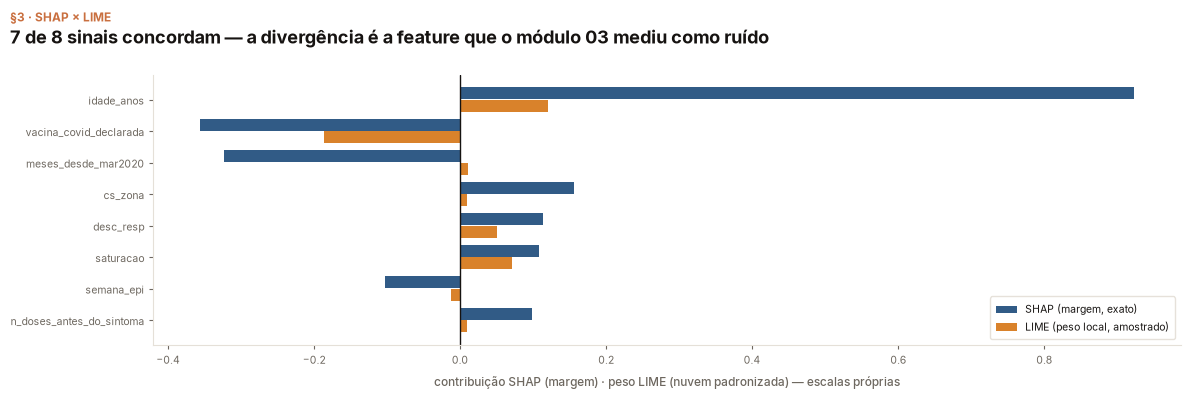

In [5]:
from lime.lime_tabular import LimeTabularExplainer

train = g[g["split"] == "train"].reset_index(drop=True)
CATS = {c: g[c].cat.categories for c in M.CATEGORICAS}
ORDEM = list(M.FEATURES)
IDX_CAT = [ORDEM.index(c) for c in M.CATEGORICAS]
IDX_BOOL = [ORDEM.index(c) for c in M.BOOLEANAS]


def para_matriz(df):
    cols = []
    for c in ORDEM:
        if c in M.CATEGORICAS:
            cols.append(df[c].cat.codes.to_numpy(dtype=np.float64))
        else:
            cols.append(df[c].to_numpy(dtype=np.float64))
    return np.column_stack(cols)


def reconstruir(arr):
    df = pd.DataFrame(np.asarray(arr, dtype=np.float64), columns=ORDEM)
    for c in M.CATEGORICAS:
        cod = np.clip(np.rint(df[c].to_numpy()), 0, len(CATS[c]) - 1).astype(int)
        df[c] = pd.Categorical.from_codes(cod, categories=CATS[c])
    for c in M.BOOLEANAS:
        df[c] = df[c] >= 0.5
    return df


def predict_fn(arr):
    df = reconstruir(arr).assign(y_obito=0, split="test")
    x, _, _ = M.design_matrix(df)
    return xgb.predict_proba(x)


X_train = para_matriz(train)
x_pac = para_matriz(pd.DataFrame([paciente[ORDEM]]).astype(train[ORDEM].dtypes))[0]
exp = LimeTabularExplainer(
    X_train, mode="classification", feature_names=ORDEM,
    categorical_features=IDX_CAT + IDX_BOOL,
    categorical_names={ORDEM.index(c): list(CATS[c]) for c in M.CATEGORICAS},
    discretize_continuous=False, random_state=RANDOM_STATE)
e = exp.explain_instance(x_pac, predict_fn, num_features=40, num_samples=5000)
pesos_lime = {}
for f, w in e.as_list():
    pesos_lime[f.split("=")[0].strip()] = w

top8 = [NOMES[j] for j in np.argsort(-np.abs(c_pac[:-1]))[:8]]
print("feature                     SHAP (margem)   LIME (peso)   sinais")
iguais = 0
for c in top8:
    s = float(c_pac[NOMES.index(c)])
    w = pesos_lime.get(c, 0.0)
    ok = np.sign(s) == np.sign(w)
    iguais += int(ok)
    print(f"{c:26s} {s:+13.4f} {w:+12.4f}   {'concordam' if ok else 'DIVERGEM'}")
print(f"\nconcordância de sinal no top-8 SHAP: {iguais}/8 — a divergência é a")
print("feature que o módulo 03 mediu como plano-no-CP/ruído: onde não há")
print("sinal, não há direção para dois métodos concordarem.")

# comparação de MÉTODOS, não de classes: azul é a série primária (SHAP) e âmbar
# o segundo braço (LIME) — o par azul/terracota fica reservado para o sinal de phi.
fig, ax = plt.subplots(figsize=SP.FAIXA)
ys = np.arange(len(top8))[::-1]
shap_v = [float(c_pac[NOMES.index(c)]) for c in top8]
lime_v = [pesos_lime.get(c, 0.0) for c in top8]
ax.barh(ys + 0.2, shap_v, height=0.38, color=SP.AZUL,
        label="SHAP (margem, exato)")
ax.barh(ys - 0.2, lime_v, height=0.38, color=SP.AMBAR,
        label="LIME (peso local, amostrado)")
ax.set_yticks(ys, top8)
ax.axvline(0, color=SP.ESCURO, lw=1)
ax.set_xlabel("contribuição SHAP (margem) · peso LIME (nuvem padronizada) — escalas próprias")
SP.sem_grade(ax)
SP.titulo(fig,
          f"{iguais} de 8 sinais concordam — a divergência é a feature que o "
          f"módulo 03 mediu como ruído",
          "§3 · shap × lime")
ax.legend(loc="lower right")
SP.salvar(fig, "shap_passo_3_vs_lime")
plt.show()

**O que olhar**

- 7 de 8 sinais concordam. As magnitudes não são comparáveis (φ em
  margem exata contra peso de reta em nuvem padronizada) — o que pode e
  deve bater é a direção.
- A única divergência é `meses_desde_mar2020`: SHAP -0,3235 contra LIME
  +0,0108. É exatamente a feature que o módulo 03 mediu como plana no CP
  / ruído de semente. Dois métodos discordarem onde não há sinal não é
  defeito de nenhum: é o que ruído parece.
- Onde há sinal, os dois o encontram com folga: idade +0,9231 e +0,1200;
  vacinação declarada -0,3562 e -0,1860.

## §4 — O retrato global: bar + beeswarm

O cap. 18 constrói o global como agregação dos locais — "the Shapley
values are the 'atomic unit' of the global interpretations". À esquerda,
a média de |φ| (a importância SHAP); à direita, o beeswarm: um ponto por
paciente, e a cor agora codifica o **valor** da feature na rampa de
intensidade (claro = baixo, escuro = alto).

top-10 global por média|SHAP| no teste, contra o gain do treino:
feature                     média|SHAP|   posto(gain)
idade_anos                      0.9007   1
vacina_covid_declarada          0.3318   3
meses_desde_mar2020             0.2873   19
saturacao                       0.2091   7
regiao                          0.1297   17
desc_resp                       0.1294   6
dispneia                        0.1251   4
out_morbi                       0.1222   9
semana_epi                      0.1128   16
cs_escol_n                      0.0978   24


figura: figures_generated/shap_passo_4_global.png


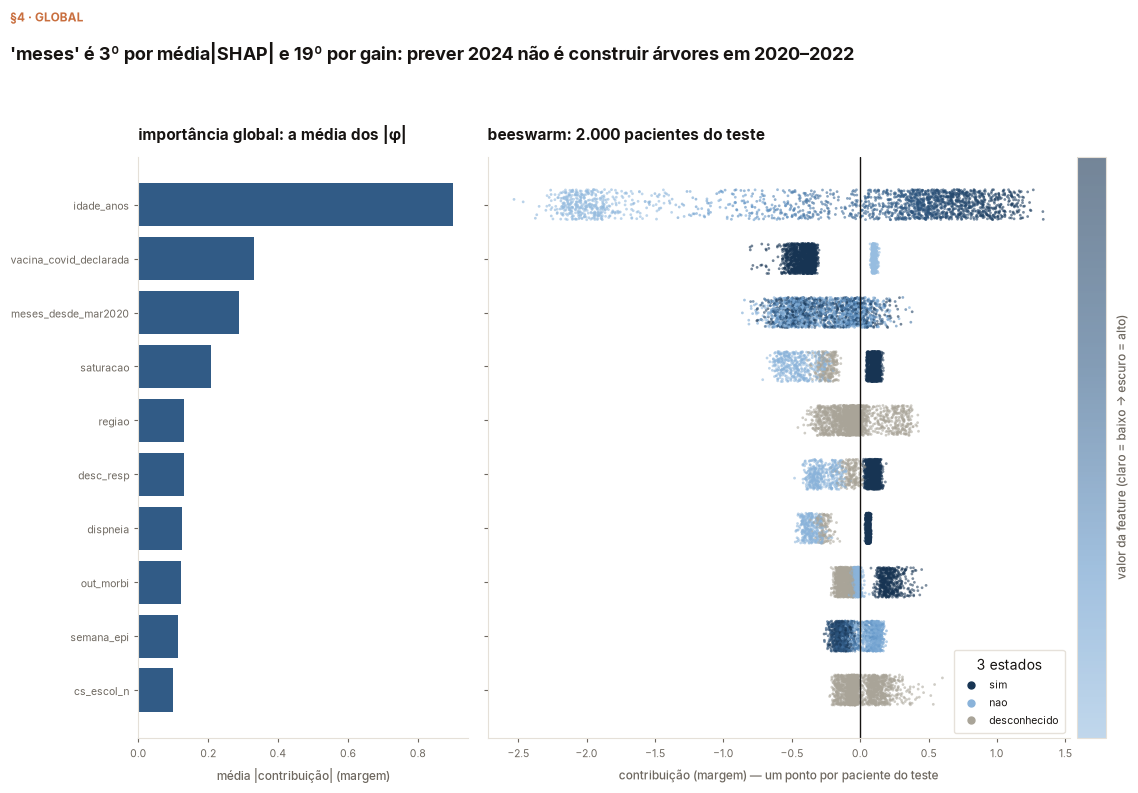

In [6]:
mabs = np.abs(contrib[:, :-1]).mean(axis=0)
og = list(np.argsort(-mabs)[:10])
gain = booster.get_score(importance_type="gain")
postos_gain = {c: r + 1 for r, (c, _) in enumerate(
    sorted(gain.items(), key=lambda kv: -kv[1]))}
print("top-10 global por média|SHAP| no teste, contra o gain do treino:")
print("feature                     média|SHAP|   posto(gain)")
for j in og:
    c = NOMES[j]
    print(f"{c:26s} {mabs[j]:11.4f}   {postos_gain.get(c, '—')}")

rng = np.random.default_rng(RANDOM_STATE)
sub = rng.choice(len(contrib), size=2000, replace=False)
# a cor deixa de ser o sinal e passa a ser o VALOR da feature: rampa ordinal de
# intensidade para numéricas e booleanas, e os três estados na mesma rampa —
# com o desconhecido no cinza-claro do "não sei".
CLARO, ESCURO_RAMPA = SP.rampa(2)
TRES = {"sim": ESCURO_RAMPA, "nao": CLARO, "desconhecido": SP.CINZA_CLARO}

fig, (axb, axs_) = plt.subplots(1, 2, figsize=SP.PAINEL, sharey=True,
                                gridspec_kw={"width_ratios": [1, 2.1]})
ys = np.arange(len(og))[::-1]
# barra de magnitude: |phi| não tem sinal, então a série primária (azul) e não
# o par de classe.
axb.barh(ys, [mabs[j] for j in og], color=SP.AZUL)
axb.set_yticks(ys, [NOMES[j] for j in og])
axb.set_xlabel("média |contribuição| (margem)")
axb.set_title("importância global: a média dos |φ|", loc="left")
SP.sem_grade(axb)
mapa = None
for y, j in zip(ys, og):
    c = NOMES[j]
    xs = contrib[sub, j]
    jit = rng.uniform(-0.28, 0.28, len(xs))
    if c in M.NUMERICAS or c in M.BOOLEANAS:
        v = teste[c].to_numpy(dtype=float)[sub]
        mapa = axs_.scatter(xs, y + jit, s=4, c=v, cmap=RAMPA, alpha=0.6)
    else:
        vals = teste[c].astype(str).to_numpy()[sub]
        cores = [TRES.get(u, SP.CINZA_CLARO) for u in vals]
        axs_.scatter(xs, y + jit, s=4, c=cores, alpha=0.55)
axs_.axvline(0, color=SP.ESCURO, lw=1)
SP.sem_grade(axs_)
axs_.set_xlabel("contribuição (margem) — um ponto por paciente do teste")
axs_.set_title("beeswarm: 2.000 pacientes do teste", loc="left")
cb = fig.colorbar(mapa, ax=axs_, pad=0.01)
cb.set_ticks([])
cb.set_label("valor da feature (claro = baixo → escuro = alto)")
handles = [plt.Line2D([], [], marker=SP.MARCADOR_REAL, ls="", color=v, label=k)
           for k, v in TRES.items()]
axs_.legend(handles=handles, loc="lower right", title="3 estados")
posto_shap = [NOMES[j] for j in og].index("meses_desde_mar2020") + 1
posto_gain = postos_gain["meses_desde_mar2020"]
SP.titulo(fig,
          f"'meses' é {posto_shap}º por média|SHAP| e {posto_gain}º por gain: "
          f"prever 2024 não é construir árvores em 2020–2022",
          "§4 · global")
SP.salvar(fig, "shap_passo_4_global")
plt.show()

**O que olhar**

- **idade** domina, com média|φ| 0,9007, e o gradiente de cor é limpo:
  idade alta (tom escuro) → φ positivo. A relação é monotônica no
  agregado.
- **vacina_covid_declarada** abre em dois grumos: declarada (o tom
  escuro, valor True) com φ negativo, não declarada (o tom claro) com φ
  positivo. Proteção num sentido, risco-por-ausência no outro.
- **meses** é 3º por média|SHAP| (0,2873) e **19º por gain** —
  importância para as predições de 2024 não é importância para construir
  as árvores em 2020–2022. A deriva de regime do módulo 02, vista pela
  atribuição.
- As caudas horizontais longas (pacientes individuais com φ extremos)
  são o que nenhuma média mostra — e são o motivo de o global do SHAP
  começar pelo local.

## §5 — Dependence plot: a dispersão vertical É a interação

O gráfico que o cap. 18 usa no lugar do PDP: φ(feature) contra o valor
da feature, um ponto por paciente. Se φ dependesse só da própria
feature, os pontos formariam uma curva fina; **a dispersão vertical é
interação com outras features** — e a cor diz com quem: aqui, o
calendário, do claro (início da pandemia) ao escuro (2024).

O teste sozinho cobre só 2024; a interação que interessa é **entre
eras**, então este gráfico usa a amostra inteira (2020–2024) — dito no
título, não escondido.

figura: figures_generated/shap_passo_5_dependencia.png


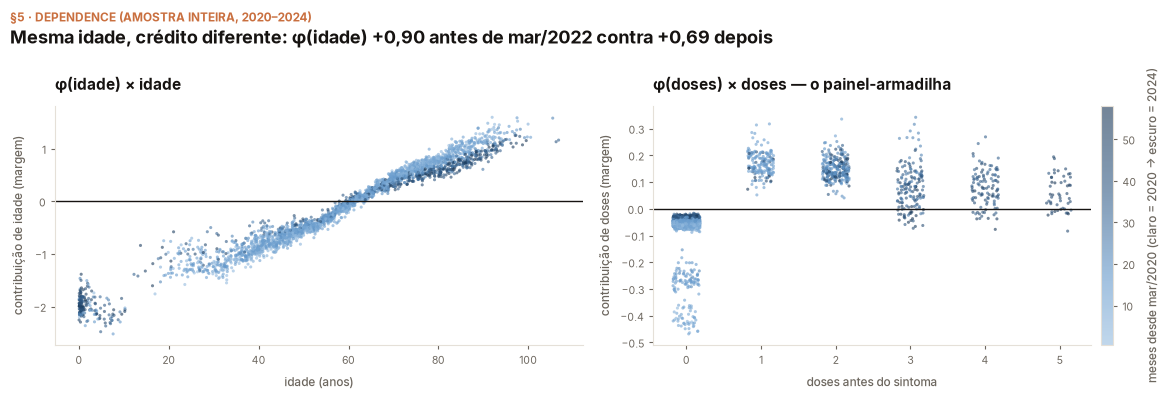

idade 78–90: φ(idade) médio +0.901 em quem adoeceu antes de mar/2022 vs +0.689 depois (n = 21.827 / 12.743)
3+ doses: φ(doses) médio +0.078 — e o painel mostra o sinal virando com a era (cor)
mesma idade, contribuição diferente — a cor (meses) ordena a dispersão:
é a interação idade × meses que o internals §3 aponta como a mais forte.


In [7]:
# o teste é só 2024 (meses 46-58); a interação idade × meses é ENTRE ERAS,
# então este gráfico usa a amostra inteira — dito no título e na barra de cor
dm_tudo = dmatrix(g)
contrib_tudo = booster.predict(dm_tudo, pred_contribs=True)
j_id = NOMES.index("idade_anos")
j_do = NOMES.index("n_doses_antes_do_sintoma")
rng = np.random.default_rng(RANDOM_STATE)
sub = rng.choice(len(g), size=3000, replace=False)
meses_v = g["meses_desde_mar2020"].to_numpy(dtype=float)[sub]

# cor = QUANDO o paciente adoeceu, na mesma rampa ordinal do §4 (claro = começo
# da pandemia, escuro = 2024); a linha do zero é objeto do modelo, em escuro.
fig, (a1, a2) = plt.subplots(1, 2, figsize=SP.FAIXA)
sc = a1.scatter(g["idade_anos"].to_numpy(dtype=float)[sub],
                contrib_tudo[sub, j_id], s=5, c=meses_v, cmap=RAMPA, alpha=0.6)
a1.axhline(0, color=SP.ESCURO, lw=1)
a1.set_xlabel("idade (anos)")
a1.set_ylabel("contribuição de idade (margem)")
a1.set_title("φ(idade) × idade", loc="left")
doses_x = g["n_doses_antes_do_sintoma"].to_numpy(dtype=float)[sub]
a2.scatter(doses_x + rng.uniform(-0.18, 0.18, len(sub)),
           contrib_tudo[sub, j_do], s=5, c=meses_v, cmap=RAMPA, alpha=0.6)
a2.axhline(0, color=SP.ESCURO, lw=1)
a2.set_xlabel("doses antes do sintoma")
a2.set_ylabel("contribuição de doses (margem)")
a2.set_title("φ(doses) × doses — o painel-armadilha", loc="left")
SP.sem_grade(a1, a2)
cb = fig.colorbar(sc, ax=a2, pad=0.02)
cb.set_label("meses desde mar/2020 (claro = 2020 → escuro = 2024)")

# a leitura, impressa: mesma idade, contribuições diferentes — quem separa?
idade_v = g["idade_anos"].to_numpy(dtype=float)
meses_g = g["meses_desde_mar2020"].to_numpy(dtype=float)
faixa = (idade_v >= 78) & (idade_v <= 90)
cedo = faixa & (meses_g < 24)
tarde = faixa & (meses_g >= 24)
phi_cedo = float(contrib_tudo[cedo, j_id].mean())
phi_tarde = float(contrib_tudo[tarde, j_id].mean())
SP.titulo(fig,
          f"Mesma idade, crédito diferente: φ(idade) {SP.pt(phi_cedo, 2, sinal=True)} "
          f"antes de mar/2022 contra {SP.pt(phi_tarde, 2, sinal=True)} depois",
          "§5 · dependence (amostra inteira, 2020–2024)")
SP.salvar(fig, "shap_passo_5_dependencia")
plt.show()

print(f"idade 78–90: φ(idade) médio {phi_cedo:+.3f} "
      f"em quem adoeceu antes de mar/2022 vs {phi_tarde:+.3f} "
      f"depois (n = {int(cedo.sum()):,} / {int(tarde.sum()):,})".replace(",", "."))
d0 = (doses := g["n_doses_antes_do_sintoma"].to_numpy(dtype=float)) >= 3
print(f"3+ doses: φ(doses) médio {contrib_tudo[d0, j_do].mean():+.3f} — "
      f"e o painel mostra o sinal virando com a era (cor)")
print("mesma idade, contribuição diferente — a cor (meses) ordena a dispersão:")
print("é a interação idade × meses que o internals §3 aponta como a mais forte.")

**O que olhar**

- **φ(idade)**: a curva sobe limpa — e nos idosos ela se abre em duas
  bandas por cor: entre 78 e 90 anos, φ médio **+0,901** em quem adoeceu
  antes de mar/2022 (tons claros) contra **+0,689** depois (tons
  escuros). Mesma idade, crédito diferente — é a interação idade × meses
  que o internals §3 identifica como a mais forte do modelo, agora
  visível.
- **φ(doses)**: o painel-armadilha, e a leitura errada nº 3 do cap. 17
  em carne viva. φ(doses) é **positivo** nos vacinados (+0,078 médio em
  3+ doses) — e isso não diz "vacina mata": o crédito protetor mora na
  `vacina_covid_declarada`, quase colinear (o grumo escuro em φ negativo
  do §4); o que sobra para a contagem de doses é marcar **quem** se
  vacinou — os grupos priorizados por risco — e **quando**. φ > 0 não
  significa "aumentar a feature aumenta p"; o contrafactual dessa
  pergunta é o módulo 04, que mediu a resposta (subir doses quase não
  move p).
- E repare no que **não** há: ponto claro (era pré-campanha) fora de
  doses = 0. O dado real respeita a cerca do módulo 00 — os vizinhos
  sintéticos do módulo 03 a violavam em 28%.

O cap. 17 recomenda parear Shapley com perfis ceteris paribus — é a
ponte com o módulo 01: o CP responde "e se ESTE paciente tivesse outra
idade?"; o dependence responde "como o modelo reparte o crédito entre
pacientes que existem?". As duas perguntas se completam e nenhuma
substitui a outra.

## §6 — Caminho × intervenção: qual condicional você quer?

Existem dois TreeSHAP (cap. 18): o **path-dependent** preenche as
coalizões ausentes seguindo as frequências dos caminhos da própria
árvore — herda as correlações do treino; o **interventional** quebra as
correlações de propósito, substituindo os ausentes por valores de um
fundo real. Molnar registra que o pacote `shap` mudou seu default para o
interventional; o `pred_contribs` do XGBoost é o path-dependent — e em
vez de fingir que a diferença não existe, medimos: o interventional sai
na mão, por amostragem de permutações (Štrumbelj & Kononenko, 2014), no
mesmo espaço de margem.

Shapley por permutação (interventional. Štrumbelj & Kononenko 2014): 60 permutações × fundo de 200 — 2.460 linhas avaliadas

feature                     pred_contribs   permutação   diferença
idade_anos                       +0.9231      +1.0270     +0.1039
vacina_covid_declarada           -0.3562      -0.5127     -0.1565
meses_desde_mar2020              -0.3235      -0.2685     +0.0550
cs_zona                          +0.1558      +0.1660     +0.0102
desc_resp                        +0.1142      +0.1167     +0.0025
saturacao                        +0.1085      +0.1504     +0.0419
semana_epi                       -0.1029      -0.1165     -0.0136
n_doses_antes_do_sintoma         +0.0987      +0.2398     +0.1410


figura: figures_generated/shap_passo_6_interventional.png


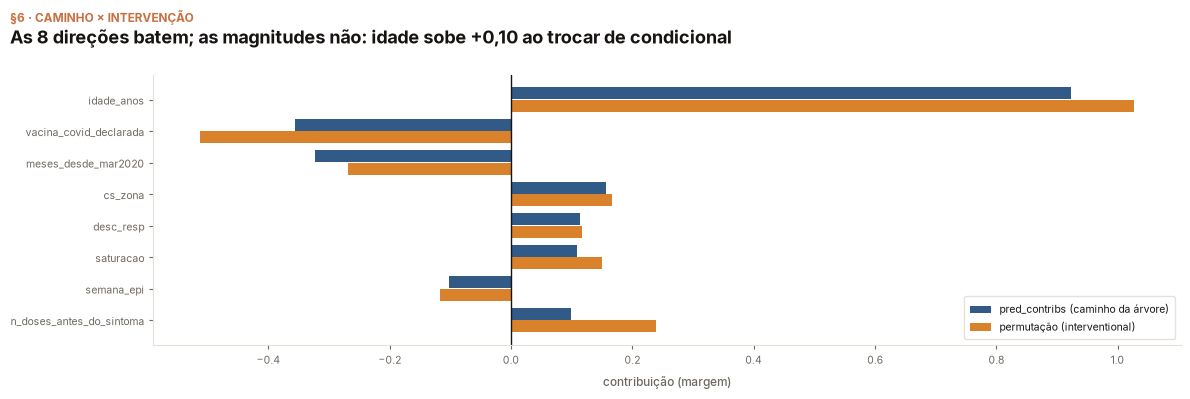

In [8]:
train_pool = g[g["split"] == "train"].reset_index(drop=True)
fundo = train_pool.sample(200, random_state=RANDOM_STATE).reset_index(drop=True)
rng = np.random.default_rng(RANDOM_STATE)
N_PERM = 60

phi = {c: 0.0 for c in M.FEATURES}
hibridos = []
for t in range(N_PERM):
    bg = fundo.iloc[int(rng.integers(len(fundo)))]
    ordem_f = list(rng.permutation(M.FEATURES))
    linha = {c: bg[c] for c in g.columns}
    linhas = [dict(linha)]
    for c in ordem_f:
        linha[c] = paciente[c]
        linhas.append(dict(linha))
    frame = pd.DataFrame(linhas).astype(g.dtypes)
    hibridos.append(frame)
    m = booster.predict(dmatrix(frame), output_margin=True)
    for k, c in enumerate(ordem_f):
        phi[c] += float(m[k + 1] - m[k]) / N_PERM

print(f"Shapley por permutação (interventional, Štrumbelj & Kononenko 2014): "
      f"{N_PERM} permutações × fundo de {len(fundo)} — "
      f"{N_PERM * (len(M.FEATURES) + 1):,} linhas avaliadas".replace(",", "."))
top8 = [NOMES[j] for j in np.argsort(-np.abs(c_pac[:-1]))[:8]]
print("\nfeature                     pred_contribs   permutação   diferença")
for c in top8:
    s = float(c_pac[NOMES.index(c)])
    p_i = phi[c]
    print(f"{c:26s} {s:+13.4f} {p_i:+12.4f} {p_i - s:+11.4f}")

# a comparação NÃO é sobre classe: são dois condicionamentos do mesmo phi. Azul
# é a série primária (o exato de caminho) e âmbar o segundo braço (a intervenção).
fig, ax = plt.subplots(figsize=SP.FAIXA)
ys = np.arange(len(top8))[::-1]
ax.barh(ys + 0.2, [float(c_pac[NOMES.index(c)]) for c in top8], height=0.38,
        color=SP.AZUL, label="pred_contribs (caminho da árvore)")
ax.barh(ys - 0.2, [phi[c] for c in top8], height=0.38,
        color=SP.AMBAR, label="permutação (interventional)")
ax.set_yticks(ys, top8)
ax.axvline(0, color=SP.ESCURO, lw=1)
ax.set_xlabel("contribuição (margem)")
SP.sem_grade(ax)
d_idade = phi["idade_anos"] - float(c_pac[NOMES.index("idade_anos")])
SP.titulo(fig,
          f"As 8 direções batem; as magnitudes não: idade sobe "
          f"{SP.pt(d_idade, 2, sinal=True)} ao trocar de condicional",
          "§6 · caminho × intervenção")
ax.legend(loc="lower right")
SP.salvar(fig, "shap_passo_6_interventional")
plt.show()

**O que olhar**

- As direções batem nas 8; as magnitudes divergem onde as correlações
  moram: idade +0,9231 → +1,0270, vacinação -0,3562 → -0,5127, doses
  +0,0987 → +0,2398.
- A diferença mistura condicionamento com ruído de Monte Carlo — o
  internals §4 separa os dois e mostra as estimativas centrando em
  **outra resposta** (+1,037), não no exato de caminho (+0,9231).
- O preço da barra âmbar: 2.460 avaliações do modelo em linhas
  fabricadas, contra uma única predição da barra azul. O §7 conta quantas
  dessas linhas são pacientes que não poderiam existir.

## §7 — As coalizões são Frankensteins

O preço do interventional, contado. Marginalizar "quebrando correlações"
significa avaliar o modelo em **híbridos**: features do paciente
enxertadas em pacientes de fundo. O curso inteiro perguntou "quem são as
linhas que o método entrega ao modelo?" — a mesma `gate_impossible`
fecha o arco no último método (o contexto de cada híbrido é o do
paciente de fundo, que é real; o enxerto é que fabrica contradição).

In [9]:
todos = pd.concat(hibridos, ignore_index=True)
# a mesma régua dos módulos 00-04, aberta nos três motivos
motivos = M.gate_reasons(todos)
imp = motivos.any(axis=1)
portao = motivos["portao"].mean()
pre = motivos["pre_campanha"].mean()
fora = motivos["fora_coorte"].mean()
print(f"linhas híbridas avaliadas pela permutação: {len(todos):,}".replace(",", "."))
print(f"impossíveis pela gate_impossible: {100 * imp.mean():.2f}%")
print(f"  portão {100 * portao:.2f}% | dose pré-campanha {100 * pre:.2f}% | "
      f"fora da coorte {100 * fora:.2f}%")
print()
print("o contexto de cada híbrido é o do paciente de fundo (o fator_risc_portao")
print("dele é um valor real registrado); o enxerto das features do paciente-alvo")
print("em cima é que fabrica as contradições — coalizões são Frankensteins.")

linhas híbridas avaliadas pela permutação: 2.460
impossíveis pela gate_impossible: 23.09%
  portão 15.37% | dose pré-campanha 8.17% | fora da coorte 0.00%

o contexto de cada híbrido é o do paciente de fundo (o fator_risc_portao
dele é um valor real registrado); o enxerto das features do paciente-alvo
em cima é que fabrica as contradições — coalizões são Frankensteins.


## O que o livro diz

Do Molnar, caps. [17](https://christophm.github.io/interpretable-ml-book/shapley.html) e
[18](https://christophm.github.io/interpretable-ml-book/shap.html):

> "The difference between the prediction and the average prediction is
> fairly distributed among the feature values of the instance — the
> Efficiency property of Shapley values." (cap. 17, Strengths)

É a propriedade que separa SHAP de LIME — e ela é *verificável*, não
prometida: desvio 1,05×10⁻⁵ aqui.

Das limitações que os capítulos listam, quatro aparecem medidas ou
demarcadas neste módulo:

| limitação (caps. 17–18) | neste módulo |
|---|---|
| φ é fácil de ler errado (não é contrafactual, não é causal) | §3 e §5: a interpretação correta dita com o CP do módulo 01 ao lado — o par que o cap. 17 recomenda |
| a marginalização usa a distribuição marginal e ignora dependência | §7: 23,1% dos híbridos avaliados são pacientes impossíveis, pela mesma cerca dos módulos 00–04 |
| path-dependent "can produce unintuitive attributions" | §6: os dois condicionamentos medidos lado a lado, com a diferença quantificada |
| Shapley não é método esparso — usa todas as features | o waterfall agrega "31 outras" honestamente: φ pequeno não é φ zero (o dummy é testado no internals §1) |

Crédito a quem pertence: os axiomas são de Shapley (1953); o jogo-da-
predição e o TreeSHAP, de Lundberg; o estimador do §6, de Štrumbelj &
Kononenko (2014); as limitações, do livro. A contribuição do módulo é a
contagem — eficiência, dummy, Frankensteins — num caso auditável.

## Fechamento — o curso inteiro numa pergunta

O SHAP fecha o arco com a única atribuição que **soma** (axioma,
verificado), **não oscila** (determinística — 3 refits bit-idênticos,
internals §1) e custa uma predição. O que ele não decide por você é a
condicional (§6) — e a escolha tem um preço mensurável em pacientes que
não existem (§7).

| módulo | pergunta | quem o método entrega ao modelo |
|---|---|---|
| 01 CP | e se mudar UMA coisa? | o paciente, com um campo torcido |
| 02 ICE | isso, para todo mundo? | 200 pacientes torcidos em fila |
| 03 LIME | que reta explica a vizinhança? | uma nuvem sem dono |
| 04 CF | o que mudaria a decisão? | candidatos de busca — e a lista de alavancas decide |
| 05 SHAP | quanto cada campo contribuiu? | coalizões — caminhos da árvore, ou Frankensteins |

A pergunta que sobreviveu aos cinco métodos: **quem são as linhas** — e
a resposta coube, as cinco vezes, na mesma função de dez linhas que o
curso escreveu uma vez no módulo 00. Explicar um modelo é, antes de
tudo, saber o que você acabou de dar de comer a ele.

**Referências**

- Shapley (1953), *A Value for n-Person Games* — o teorema da partilha
  justa que tudo aqui instancia.
- Lundberg & Lee (2017), *NeurIPS* — [A Unified Approach to Interpreting
  Model Predictions](https://arxiv.org/abs/1705.07874): o jogo-da-predição.
- Lundberg et al. (2020), *Nature Machine Intelligence* 2 —
  [TreeSHAP](https://doi.org/10.1038/s42256-019-0138-9), o algoritmo por
  trás de `pred_contribs` e dos gráficos globais do §4.
- Štrumbelj & Kononenko (2014), *KAIS* 41(3) — o estimador por
  amostragem de permutações do §6.
- Molnar, *Interpretable Machine Learning*, 3ª ed., caps.
  [17](https://christophm.github.io/interpretable-ml-book/shapley.html) e
  [18](https://christophm.github.io/interpretable-ml-book/shap.html).
- Ferramentas: `xgboost` 3.4.1 (`pred_contribs`, `pred_interactions`) e
  `lime` 0.2.0.1 — as versões pinadas em `requirements.txt`.
- Base, modelo, paciente e cercas: módulo 00 —
  [MODEL.md](../../00-dataset/MODEL.md).